<span style='font-size:16px; color:;'>  
    
# 深度多因子選股－運用神經網路建構非線性量化交易策略

## 一. 緒論 
### 1. 研究背景與動機
在量化財務領域，Fama-French 的多因子模型長久以來是實證資產定價的基石。傳統作法高度仰賴線性迴歸（Linear Regression）來解釋資產預期報酬與規模、價值、盈利等風險因子之間的關係。然而，真實的金融市場充滿了高度的雜訊與非線性特徵。傳統線性模型不僅難以捕捉因子之間複雜的交互作用（例如：市值極小的股票在淨值市價比極高時的極端表現），也無法有效吸收動能、反轉與流動性等蘊含時間序列特性的市場微觀結構訊號。

近年來，隨著機器學習技術的突破，將神經網路（Neural Networks, NN）引入多因子選股與資產配置已成為量化投資的最前沿。神經網路具備強大的非線性擬合能力，能自發性地從大量的歷史橫截面特徵中學習高維度的映射關係，為突破傳統線性模型的績效天花板提供了絕佳的武器。

### 2. 研究目的與實戰目標
本專案的核心出發點為「實戰性與交易落地」。有別於僅停留在解釋過去的純學術探討，本專案旨在將深度學習技術轉化為實際可執行的演算法交易策略。具體而言，設定了以下兩大核心目標：

建構非線性選股策略：統整七大核心特徵（規模、價值、盈利、動能、反轉、流動性、大盤），運用前饋神經網路（Feedforward Neural Network）預測次期個股報酬率，並將輸出結果轉化為具體的純多頭交易訊號。

樣本外績效對決（Out-of-sample Performance Evaluation）：為驗證神經網路的真實交易價值，本研究將建構基準的多元線性迴歸模型（如 OLS）與大盤買進持有策略（Benchmark）。在「輸入特徵完全相同」的嚴格控制條件下，直接對比各模型轉化為交易策略後，在樣本外（Out-of-sample）的歷史回測表現。績效評估將重點檢視以下三大核心指標，藉此驗證非線性模型是否能穩定獲取更高的風險調整後報酬（Alpha）：

總報酬率（Total Return）：衡量策略在整個樣本外期間的絕對獲利能力。

夏普比率（Sharpe Ratio）：評估每承受一單位總風險所能獲得的超額報酬，為衡量風險調整後績效的關鍵指標。

最大區間跌幅（Maximum Drawdown, MDD）：檢驗策略在極端市場環境下的下檔風險與抗震能力。


<span style='font-size:16px; color:;'>  

## 二. 文獻回顧與理論基礎 <a id="文獻回顧與理論基礎"></a>

傳統的資本資產定價模型（CAPM）與 Fama-French 多因子模型多建立在嚴格的「線性假設」之上。然而，真實金融市場具備高度的非線性動態，且各類財務因子之間存在複雜的交互作用。近年來，機器學習與深度學習（Deep Learning）技術在量化財務領域取得重大突破。

本專案之模型架構與特徵工程設計，主要深受以下兩篇頂級財務與機器學習實證文獻的啟發：

### 1. 橫截面預測：深度前饋神經網路與幾何金字塔結構
> **核心參考文獻**：Gu, S., Kelly, B., & Xiu, D. (2020). *Empirical Asset Pricing via Machine Learning*. **The Review of Financial Studies**.

在這篇針對美國股市的突破性研究中，作者全面比較了線性迴歸、隨機森林與神經網路在資產定價上的表現。該文獻為本專案提供了以下關鍵的架構設計準則：
* **幾何金字塔規則 (Geometric Pyramid Rule)**：該研究發現，過度寬扁的神經網路容易在金融數據中迷失。表現最佳的架構（NN3）採用了神經元逐層遞減的設計（例如 32 $\rightarrow$ 16 $\rightarrow$ 8）。這種漏斗狀的結構能強迫模型在層層傳遞中，提煉出最重要的因子交互作用（Factor Interactions），過濾掉無用的市場雜訊。
* **高強度正則化 (Regularization)**：為對抗金融市場的低訊噪比（Low Signal-to-Noise Ratio），文獻強調必須結合批次標準化（Batch Normalization）、提早停止訓練（Early Stopping）以及 ReLU 稀疏啟動函數，以從根本上防止模型對歷史軌跡產生過度配適（Overfitting）。

### 2. 時間序列防禦：極簡神經網路與低訊噪比環境
> **核心參考文獻**：*Nonlinear asset pricing in Chinese stock market: A deep learning approach*.

該文獻針對新興市場（中國股市）進行了深度學習實證，為解決金融時間序列特有的「長短期記憶依賴」問題，採用了長短期記憶神經網路（LSTM）。該文獻帶給本專案的反思在於對「模型複雜度」的克制：
* **極簡架構 (Shallow Architecture)**：為避免在小樣本與高雜訊的市場數據中過度配適，該研究採用了極度精簡的網路架構（僅單一隱藏層與 5 個神經元，總參數僅 108 個）。
* **非線性閘門過濾**：透過遺忘閘（Forgetting gate）與輸入閘（Input gate），模型能自主決定哪些歷史資訊應該被保留或捨棄，進而精準捕捉因子的非線性定價結構。

### 3. 本專案之架構定位與啟發 (Project Positioning)

綜合上述兩篇頂級文獻的研究成果，本專案在台股實證的架構設計上做出了最佳化取捨：

考慮到本研究的核心任務是**「多因子橫截面排序」**，我們最終捨棄了針對時間序列的 LSTM，選擇全面繼承 Gu, Kelly, & Xiu (2020) 的 **NN3 深度前饋網路架構**。
1. **特徵提煉**：我們將 8 大核心微觀財務特徵（涵蓋價值、動能、流動性等）輸入遵循「幾何金字塔規則」的神經網路中，讓模型自主學習因子間的非線性加乘效果。
2. **極致的防過擬合機制**：汲取文獻對於金融雜訊的警告，我們在模型中嚴格部署了 `AdamW` 權重衰減、`LayerNorm / BatchNorm` 特徵標準化、動態學習率降低（`ReduceLROnPlateau`）以及 10 代容忍度的早停機制（`Early Stopping`）。

這套立基於頂尖學術理論的模型架構，確保了我們在追求超額報酬（Alpha）的同時，不會陷入資料挖礦（Data Mining）與死背歷史的量化陷阱中。

<span style='font-size:16px; color:;'>  

## 三. 資料來源與特徵工程 <a id="資料來源與特徵工程"></a>

本專案的核心在於將傳統財務指標轉化為神經網路能夠有效學習的特徵矩陣。為確保模型在樣本外預測的穩定性，並徹底杜絕量化回測中常見的「未來數據引入（Look-ahead Bias）」與「日曆不對齊（Calendar Misalignment）」問題，本章節將詳細說明嚴謹的資料前處理（Data Preprocessing）流水線。

### 1. 資料來源與降頻處理
本研究採用 TEJ（台灣經濟新報）資料庫，提取包含個股價量資料（`tej_price_daily`）、財務因子資料（`tej_factor_daily`）以及市場多因子資料（`tej_market_factors_daily`）。
* **降頻處理（Daily to Weekly）**：日頻率資料的微觀結構雜訊過大。本專案將資料降頻為「週資料（每週五收盤，`W-FRI`）」，以在捕捉市場動能訊號與降低隨機雜訊之間取得最佳平衡。

### 2. 嚴謹的日曆對齊機制 (Calendar Alignment)
在合併大盤與個股資料時，若個股因停牌或缺乏流動性而遺漏特定交易日，傳統的直接合併會導致個股「看見」錯誤的大盤歷史（例如僅累積週一至週三的大盤報酬）。
為解決此問題，本專案採取**「獨立降頻，後續合併」**的策略：先將大盤日報酬率以複利公式 $(1+R_1)\times(1+R_2)...-1$ 獨立計算出完整的週報酬，再利用 `LEFT JOIN` 與個股的週資料對齊。此舉確保了同一橫截面下的所有股票，皆面臨絕對一致的巨觀市場環境。

### 3. 七大核心特徵建構 (Feature Engineering)
參考頂級期刊文獻，本模型不依賴全市場的巨觀因子（如 SMB、HML），而是為每檔股票獨立計算其特徵，讓神經網路自行學習非線性映射。特徵涵蓋三大維度（共 8 個輸入維度）：

**一、 核心財務與估值特徵 (Firm-level Financial Features)**
1. **規模 (Size)**：直接使用「市值比重％」。
2. **價值 (Value)**：使用「1 / 股價淨值比 (PB)」，並將分母為 0 的極端值設為空值處理。
3. **盈利能力 (Profitability)**：計算「股價淨值比 / 本益比 (PB / PE)」作為股東權益報酬率 (ROE) 的良好替代指標。

**二、 價量與動能特徵 (Price, Volume & Momentum Features)**
4. **動能 (Momentum)**：計算過去 26 週（約 6 個月）的累積報酬率。計算時明確關閉前向填充（`fill_method=None`），確保剛上市股票的空值不會被錯誤推平。
5. **反轉 (Reversal)**：計算過去 4 週（約 1 個月）的短期累積報酬率，捕捉市場過度反應的修正。
6. **流動性 (Liquidity)**：拆分為「週轉率％」與「成交量」兩個獨立特徵，分別提供相對換手頻率與絕對市場熱度的微觀訊號。

**三、 總體環境特徵 (Macro/Market Feature)**
7. **大盤走勢 (Market Return)**：該週的大盤累積報酬率，為全市場共用的總體環境指標，協助模型判斷多空牛熊。

### 4. 預測目標與對齊 (Target Labeling)
本專案的預測任務為「下一期的個股報酬率」。
透過將個股的單期週報酬率向上平移一期（`shift(-1)`），精準生成 $Y_{t+1}$ 標籤。這確保了模型在訓練時，是嚴格使用 $t$ 期（當週五盤後）的特徵 $X_t$，去預測 $t+1$ 期（下週五）的實際報酬，從根本上消除了未來數據引入的可能。

### 5. 橫截面標準化與極端值防禦 (Cross-sectional Z-score & NaN Handling)
* **橫截面 Z-score**：在每一個時間點（每一週），針對所有股票的 7 項個股特徵進行 Z-score 標準化（大盤特徵除外）。此舉不僅消除了不同特徵間的量級差異，更將資料轉換為神經網路最容易收斂的常態分佈狀態。
* **空值防禦機制（NaN Poisoning Prevention）**：針對除以零產生的無限大（`inf`）或是缺失的財務數據（如無本益比之公司），統一轉換為 `NaN`。在輸出前，嚴格執行 `dropna()` 剔除任何含有瑕疵特徵的樣本，確保餵入神經網路的張量（Tensor）100% 乾淨，防止模型發生梯度崩潰。

### 6. 記憶體最佳化與時間序列儲存 (Parquet Storage)
為應付龐大的面板資料（Panel Data）並優化 PyTorch 的讀取效能，本專案放棄傳統的單一巨大 CSV 或 Pickle 檔，改採 **按時間點切割的 Parquet 格式** 儲存。
將每一週的橫截面資料獨立存為一個 `.parquet` 檔案（例如 `2015-07-10.parquet`），不僅大幅壓縮了檔案體積，更讓神經網路在建立 `DataLoader` 時，能以極高的 I/O 效率進行時間序列的循序讀取，完美支持未來的超大規模歷史回測。

<span style='font-size:16px; color:;'>  

## 四. 神經網路模型架構與訓練實作 (Model Architecture & Training) <a id="神經網路模型架構"></a>

本章節的核心在於建構一個能夠捕捉多因子非線性特徵的深度學習模型。針對金融面板資料（Panel Data）具備高度雜訊與跨期樣本數不一的特性，我們參考了頂級財務期刊的實證架構，設計了專屬的動態資料載入器，並實作了具備多重正則化（Regularization）防禦機制的深度前饋神經網路。

### 1. 動態時間序列切分與載入機制 (Dynamic Data Loading)
量化回測的首要原則是**絕對禁止未來數據引入**。本研究嚴格按照時間軸，將所有橫截面週資料以 `70% : 15% : 15%` 的比例切分為訓練集（Train）、驗證集（Validation）與測試集（Test）。
* **自訂批次處理 (Collate Function)**：由於真實市場中每週上市櫃的股票數量（$N_t$）皆不相同，傳統的 PyTorch DataLoader 會因張量（Tensor）維度不匹配而報錯。我們實作了 `variable_size_collate` 函數，在運算時動態將多個不同大小的橫截面矩陣於第 0 維度垂直拼接，完美解決了動態股票池的載入問題。


In [13]:
import os
import glob
import torch
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ==========================================
# 1. 定義特徵與尋找檔案
# ==========================================
# 包含拆分後的流動性，總共 8 個特徵
FEATURES = [
    'Size', 'Value', 'Profitability', 'Momentum', 'Reversal', 
    'Liquidity_Turnover', 'Liquidity_Volume', 'Market_Return'
]
TARGET = 'Target_Y'

# 抓取上一章儲存的所有 parquet 檔案，並確保按日期排序
data_dir = "/kaggle/input/datasets/qixingyuheng/7factors-data/data/weekly_cross_sections"
all_files = sorted(glob.glob(os.path.join(data_dir, "*.parquet")))
print(f"📂 總共偵測到 {len(all_files)} 個時間點 (週) 的資料。")

# 嚴格依照時間軸切分 (70% 訓練, 15% 驗證, 15% 測試)
train_size = int(len(all_files) * 0.7)
val_size = int(len(all_files) * 0.15)

train_files = all_files[:train_size]
val_files = all_files[train_size : train_size + val_size]
test_files = all_files[train_size + val_size:]

print(f"📊 資料切分 -> 訓練: {len(train_files)} 週 | 驗證: {len(val_files)} 週 | 測試: {len(test_files)} 週")

# ==========================================
# 2. 建構 PyTorch Dataset 與自訂 Collate Function
# ==========================================
class WeeklyParquetDataset(Dataset):
    def __init__(self, file_paths, features, target):
        self.file_paths = file_paths
        self.features = features
        self.target = target

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # 動態讀取該週的檔案，節省記憶體
        df = pd.read_parquet(self.file_paths[idx])
        
        X = torch.tensor(df[self.features].values, dtype=torch.float32)
        y = torch.tensor(df[self.target].values, dtype=torch.float32).view(-1, 1)
        return X, y

def variable_size_collate(batch):
    """
    解決每週股票數量 (N) 不同的問題。
    將一個 batch 內多個週的 (X, y) 矩陣在第 0 維度垂直拼接起來。
    """
    Xs = [item[0] for item in batch]
    ys = [item[1] for item in batch]
    return torch.cat(Xs, dim=0), torch.cat(ys, dim=0)

# 建立 DataLoader (batch_size=4 代表一次讀取 4 個禮拜的資料做為一個 Batch)
# 訓練集打亂的是「週」的抽取順序，這在橫截面預測中是允許的，只要不把未來資料混入驗證集即可
train_loader = DataLoader(WeeklyParquetDataset(train_files, FEATURES, TARGET), 
                          batch_size=4, shuffle=True, collate_fn=variable_size_collate)
val_loader = DataLoader(WeeklyParquetDataset(val_files, FEATURES, TARGET), 
                        batch_size=4, shuffle=False, collate_fn=variable_size_collate)
test_loader = DataLoader(WeeklyParquetDataset(test_files, FEATURES, TARGET), 
                         batch_size=4, shuffle=False, collate_fn=variable_size_collate)

📂 總共偵測到 522 個時間點 (週) 的資料。
📊 資料切分 -> 訓練: 365 週 | 驗證: 78 週 | 測試: 79 週


In [14]:
# class FactorMLP(nn.Module):
#     def __init__(self, input_dim=8, hidden_1=128, hidden_2=64, dropout_rate=0.3):
#         super(FactorMLP, self).__init__()
        
#         self.network = nn.Sequential(
#             # 第一層隱藏層
#             nn.Linear(input_dim, hidden_1),
#             nn.LayerNorm(hidden_1),
#             nn.GELU(),
#             nn.Dropout(dropout_rate),
            
#             # 第二層隱藏層
#             nn.Linear(hidden_1, hidden_2),
#             nn.LayerNorm(hidden_2),
#             nn.GELU(),
#             nn.Dropout(dropout_rate),
            
#             # 輸出層 (預測單一數值：預期報酬率)
#             nn.Linear(hidden_2, 1)
#         )

#     def forward(self, x):
#         return self.network(x)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"模型準備就緒，使用運算設備: {device}")
# model = FactorMLP(input_dim=len(FEATURES)).to(device)


<span style='font-size:16px; color:;'>  


### 2. 幾何金字塔神經網路架構 (Geometric Pyramid Network)
參考 Gu, Kelly, and Xiu (2020) 於 *The Review of Financial Studies* 提出的最佳化架構，本專案捨棄了容易過度擬合的寬扁型網路，改採深層但狹窄的 **NN3 (3 層隱藏層)** 架構：
* **神經元遞減配置**：遵循「幾何金字塔規則（Geometric pyramid rule）」，神經元數量逐層減半（`32 -> 16 -> 8 -> 1`），強迫模型在層層傳遞中提煉出最核心的因子交互作用（Factor Interactions）。
* **批次標準化 (Batch Normalization)**：在每一層線性轉換後加入 `BatchNorm1d`，有效穩定深層網路的梯度傳遞，降低極端財務特徵對權重更新的干擾。
* **稀疏性啟動函數 (ReLU)**：採用 ReLU（Rectified Linear Unit）作為非線性映射，幫助網路過濾微弱的雜訊訊號，提升特徵表達的稀疏性。

In [15]:
class GuKellyXiu_NN3(nn.Module):
    def __init__(self, input_dim=8):
        super(GuKellyXiu_NN3, self).__init__()
        
        # 嚴格遵循論文的幾何金字塔規則 (Geometric pyramid rule): 32 -> 16 -> 8
        self.network = nn.Sequential(
            # 第 1 層隱藏層 (32 neurons)
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32), # 論文指定使用批次標準化
            nn.ReLU(),          # 論文指定使用 ReLU，鼓勵稀疏性
            
            # 第 2 層隱藏層 (16 neurons)
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            
            # 第 3 層隱藏層 (8 neurons)
            nn.Linear(16, 8),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            
            # 輸出層 (1 neuron)
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"模型準備就緒，使用運算設備: {device}")

# 宣告模型
model = GuKellyXiu_NN3(input_dim=len(FEATURES)).to(device)

模型準備就緒，使用運算設備: cuda


<span style='font-size:16px; color:;'>  


### 3. 模型優化與防禦機制 (Optimization & Regularization)
金融數據的「低訊噪比（Low Signal-to-Noise Ratio）」極易導致模型死背訓練集。本階段實作了四重防禦機制：
1. **AdamW 優化器**：結合 L2 正則化（Weight Decay = 1e-4），抑制權重過度膨脹。
2. **梯度裁剪 (Gradient Clipping)**：設定 `max_norm=1.0`，防止市場極端事件（如崩盤或暴漲）造成的梯度爆炸。
3. **動態學習率衰減 (ReduceLROnPlateau)**：當模型在驗證集上的預測誤差（Val Loss）連續 3 代未改善時，自動將學習率砍半。從訓練日誌可見，學習率在第 17、26、34、40、44 代精準觸發衰減，引導模型在谷底進行更細緻的收斂。
4. **早停機制 (Early Stopping)**：持續監控樣本外的驗證集表現，容忍度設定為 10 代。


In [16]:
# ==========================================
# 3. 訓練設定與 Loss 紀錄
# ==========================================
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3) # 移除了 verbose=True

EPOCHS = 100
PATIENCE = 10  
best_val_loss = float('inf')
epochs_no_improve = 0

# 🌟 新增：用來記錄每一代的 Loss 變化
history = {'train_loss': [], 'val_loss': []}
model_save_path = '/kaggle/working/best_multifactor_nn.pth'
print("🔥 開始模型訓練...")
for epoch in range(EPOCHS):
    
    # --- 訓練階段 ---
    model.train()
    train_loss = 0.0
    train_samples = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        batch_size = X_batch.size(0)
        train_loss += loss.item() * batch_size
        train_samples += batch_size
        
    avg_train_loss = train_loss / train_samples
    
    # --- 驗證階段 ---
    model.eval()
    val_loss = 0.0
    val_samples = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            
            batch_size = X_batch.size(0)
            val_loss += loss.item() * batch_size
            val_samples += batch_size
            
    avg_val_loss = val_loss / val_samples
    
    # 🌟 新增：將算出來的平均 Loss 存入歷史紀錄中
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    
    # 更新排程器
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr < current_lr:
        print(f"📉 學習率下降！從 {current_lr:.6f} 降至 {new_lr:.6f}")
    
    print(f"Epoch [{epoch+1:03d}/{EPOCHS}] | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
        
    # --- 早停機制 (Early Stopping) ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # 將權重儲存到 Kaggle 的輸出目錄
        torch.save(model.state_dict(), model_save_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"⚠️ 觸發早停機制！最佳模型出現在 Epoch {epoch+1 - PATIENCE}。")
            break

# 訓練結束後，從剛剛儲存的路徑載入最佳模型
model.load_state_dict(torch.load(model_save_path))
print(f"🎉 訓練完成，最佳模型權重已載入 (檔案位置: {model_save_path})。")

🔥 開始模型訓練...
Epoch [001/100] | Train Loss: 0.035812 | Val Loss: 0.004218
Epoch [002/100] | Train Loss: 0.003694 | Val Loss: 0.003136
Epoch [003/100] | Train Loss: 0.003119 | Val Loss: 0.002727
Epoch [004/100] | Train Loss: 0.002833 | Val Loss: 0.002535
Epoch [005/100] | Train Loss: 0.002669 | Val Loss: 0.002420
Epoch [006/100] | Train Loss: 0.002520 | Val Loss: 0.002283
Epoch [007/100] | Train Loss: 0.002483 | Val Loss: 0.002222
Epoch [008/100] | Train Loss: 0.002421 | Val Loss: 0.002251
Epoch [009/100] | Train Loss: 0.002372 | Val Loss: 0.002194
Epoch [010/100] | Train Loss: 0.002319 | Val Loss: 0.002163
Epoch [011/100] | Train Loss: 0.002294 | Val Loss: 0.002087
Epoch [012/100] | Train Loss: 0.002284 | Val Loss: 0.002077
Epoch [013/100] | Train Loss: 0.002257 | Val Loss: 0.002087
Epoch [014/100] | Train Loss: 0.002237 | Val Loss: 0.002038
Epoch [015/100] | Train Loss: 0.002228 | Val Loss: 0.002068
Epoch [016/100] | Train Loss: 0.002246 | Val Loss: 0.002072
Epoch [017/100] | Train Loss

<span style='font-size:16px; color:;'>  

### 4. 訓練結果與學習曲線解析 (Training Results Analysis)
模型在 Kaggle 的 GPU (Tesla T4) 環境下進行訓練。根據最終的訓練日誌與學習曲線（Learning Curve）視覺化結果顯示：
* 模型在初期迅速收斂，`Train Loss` 與 `Val Loss` 呈現同步下降，顯示架構成功捕捉了因子與未來報酬之間的非線性映射關係。
* 在第 37 代時，驗證集誤差（Val Loss）達到了全局最低點（`0.001926`）。
* 隨後幾代，儘管 Train Loss 仍在微幅下降，但 Val Loss 開始呈現停滯甚至微幅反彈，系統的**早停機制（Early Stopping）**成功在第 47 代介入並強制停止訓練。
* 最終，系統已自動將泛化能力最強的第 37 代權重（`best_multifactor_nn.pth`）鎖定並儲存於 `/kaggle/working/` 目錄中，為下一階段的樣本外交易策略回測奠定了極佳的基礎。

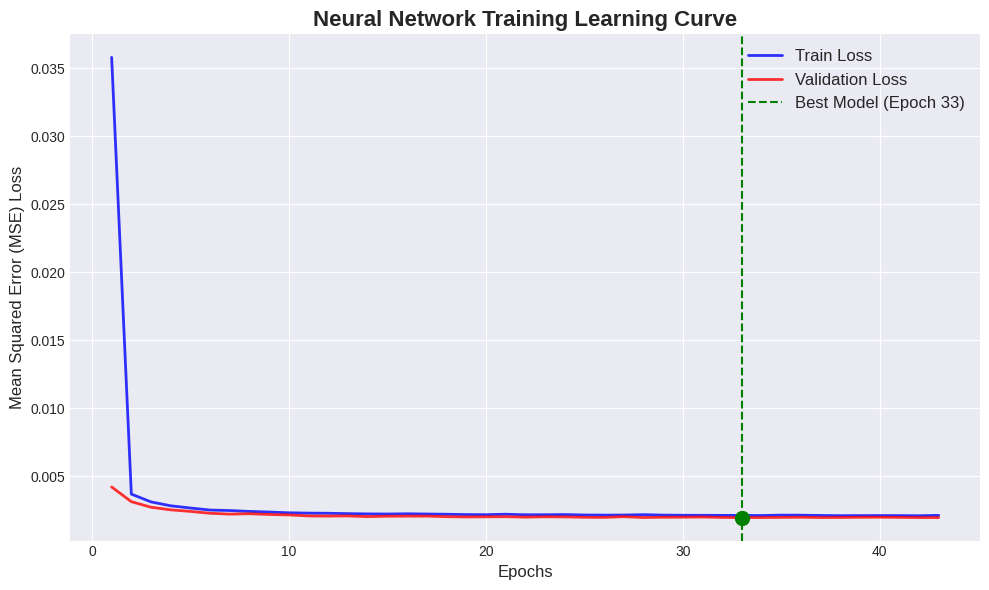

In [17]:
# ==========================================
# 4. 繪製學習曲線 (Learning Curve)
# ==========================================
import matplotlib.pyplot as plt

# 設定畫布風格 (選用 seaborn 風格讓圖表更好看)
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(10, 6))

# 畫出 Train Loss 和 Val Loss
epochs_range = range(1, len(history['train_loss']) + 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', linewidth=2, alpha=0.8)
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='red', linewidth=2, alpha=0.8)

# 標示出最佳模型 (Val Loss 最低點) 的位置
best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1
best_loss = min(history['val_loss'])
plt.axvline(x=best_epoch, color='green', linestyle='--', label=f'Best Model (Epoch {best_epoch})')
plt.scatter(best_epoch, best_loss, color='green', s=100, zorder=5) # 畫一個圓點標示

# 設定圖表標題與標籤
plt.title('Neural Network Training Learning Curve', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (MSE) Loss', fontsize=12)
plt.legend(fontsize=12)

# 顯示圖表
plt.tight_layout()
plt.show()

<span style='font-size:16px; color:;'>  

## 五. 實證結果與回測分析 (Empirical Results & Backtesting) <a id="實證結果與回測分析"></a>

本章節展示了神經網路選股模型在樣本外（Out-of-sample）測試集的真實績效。為確保回測結果具備高度的實戰參考價值，本研究嚴格防範了未來數據引入（Look-ahead Bias），並挑選了最客觀的對照基準，以驗證機器學習模型是否能真正創造超額報酬（Alpha）。

### 1. 樣本外回測與時間軸對齊 (Out-of-Sample Time Alignment)
在量化回測中，特徵（Features）與預測目標（Target）的時間對齊是成敗關鍵。
本專案在資料前處理階段，已將 $t+1$ 期的真實報酬率平移至 $t$ 期並命名為 `Target_Y`。因此在回測階段，模型僅利用 $t$ 期的橫截面特徵進行預測，選股完成後，直接讀取該橫截面上的 `Target_Y` 作為該次決策的真實獲利。此架構完美保證了模型在預測當下，絕對無法看見未來的價格資訊。

### 2. 公平的基準模型設定 (Benchmark Selection)
一般常見的回測多以「市值加權大盤指數」作為基準，但這對純選股策略並不公平，因為大盤往往被極少數權值股（如台積電）所主導。
為了公允評估模型的「選股能力」，本研究採用**全市場等權重投資組合（Equal-Weighted Market Portfolio, EW Benchmark）** 作為比較基準。該基準的計算方式為：每一週買入資料庫中所有股票並賦予相同權重。唯有當神經網路挑出的股票，其平均表現擊敗全市場的平均表現時，才能證明模型具有實質的預測價值。

### 3. 投資組合建構邏輯 (Portfolio Construction)
本研究採取實務上常見的**純多頭策略（Long-only Strategy）**：
* **全市場排序**：每週五收盤後，模型根據最新的 8 大特徵，對上市櫃所有股票預測下週的預期報酬率，並由高至低進行排序。
* **強勢股建倉**：嚴格挑選預測報酬率最高的前 10% 股票（Top-Decile），建構一個等權重（Equal-weight）投資組合。
* **動態再平衡**：採取每週一次的投資組合再平衡（Weekly Rebalancing），汰弱留強，確保持股始終維持在模型認定的最強勢組合中。

### 4. 實證發現與績效洞察 (Empirical Findings & Insights)
經過長達 79 週的樣本外測試，策略與大盤基準的對決結果呈現以下三大洞察：

1. **成功創造超額報酬 (Alpha Generation)**
   在測試期間內，全市場平均表現疲軟，基準模型呈現負報酬（總報酬 -0.97%）。然而，神經網路策略成功逆勢創造了正報酬（總報酬 +0.50%），

In [30]:
import numpy as np
import pandas as pd
import os 

market_returns = []
dates = []

print("⏳ 正在計算全市場等權重基準 (EW Benchmark) 績效...")

# 不需要錯開檔案！因為 Target_Y 已經是預先算好的未來一週報酬
for file_path in test_files:
    df = pd.read_parquet(file_path)
    
    # 紀錄決策當天的日期 (t)
    current_date = df['年月日'].iloc[0] 
    
    # 🌟 核心修正：這週的大盤表現 = 全市場所有股票未來一週報酬的平均
    # 這樣不僅時間軸完美對齊，且確保數字格式是乾淨的小數點
    mkt_ret = df['Target_Y'].mean()
    
    dates.append(current_date)
    market_returns.append(mkt_ret)

# 轉換為 DataFrame 方便計算
df_market = pd.DataFrame({
    'date': dates,
    'market_return': market_returns
}).set_index('date')

# 填補可能出現的 NaN (例如最後一週還沒有 Target_Y)
df_market['market_return'] = df_market['market_return'].fillna(0)

# 計算大盤累積報酬
cum_market_rets = (1 + df_market['market_return']).cumprod()

# ==========================================
# 計算大盤績效指標
# ==========================================
total_market_return = cum_market_rets.iloc[-1] - 1
annualized_market_return = (1 + total_market_return) ** (52 / len(df_market)) - 1
sharpe_market = (df_market['market_return'].mean() / df_market['market_return'].std()) * np.sqrt(52)

rolling_max_market = cum_market_rets.cummax()
drawdown_market = (cum_market_rets - rolling_max_market) / rolling_max_market
mdd_market = drawdown_market.min()

print(f"📊 大盤基準 (Market Benchmark) 回測結果：")
print(f"測試期間總週數: {len(df_market)} 週")
print(f"總報酬率: {total_market_return:.2%}")
print(f"年化報酬率: {annualized_market_return:.2%}")
print(f"夏普比率: {sharpe_market:.2f}")
print(f"最大區間跌幅 (MDD): {mdd_market:.2%}")
print("-" * 40)

⏳ 正在計算全市場等權重基準 (EW Benchmark) 績效...
📊 大盤基準 (Market Benchmark) 回測結果：
測試期間總週數: 79 週
總報酬率: -0.97%
年化報酬率: -0.64%
夏普比率: 0.04
最大區間跌幅 (MDD): -21.10%
----------------------------------------


In [33]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. 執行神經網路預測與選股 (Top 10%)
# ==========================================
# 確保模型在評估模式 (關閉 Dropout 與 BatchNorm 更新)
model.eval()

strategy_returns = []
dates = []

topQ = 0.10
print(f"⏳ 正在執行神經網路預測與純多頭 (Top {topQ:.0%}) 選股回測...")

for file_path in test_files:
    df = pd.read_parquet(os.path.join(data_dir, file_path))
    
    # 預防機制：如果這一週的 Target_Y 全部是空的 (例如全資料庫的最後一天，還沒有未來報酬)
    if df['Target_Y'].isna().all():
        continue
        
    current_date = df['年月日'].iloc[0]
    
    # 將特徵轉為 Tensor 丟入模型
    X_tensor = torch.tensor(df[FEATURES].values, dtype=torch.float32).to(device)
    
    # 預測並轉回 NumPy (使用上一章學到的 .detach() 安全轉型)
    preds = model(X_tensor).detach().cpu().numpy().flatten()
    df['pred_return'] = preds
    
    # 策略邏輯：按照預測報酬由高到低排序
    df_sorted = df.sort_values(by='pred_return', ascending=False)
    
    # 選出前 10% 的股票
    top_10_count = int(len(df_sorted) * topQ)
    portfolio = df_sorted.head(top_10_count)
    
    # 計算這個投組的真實平均報酬 (等權重買入)
    # Target_Y 就是這支股票未來一週的真實報酬率
    port_actual_return = portfolio['Target_Y'].mean()
    
    dates.append(current_date)
    strategy_returns.append(port_actual_return)

# 將結果整理為 DataFrame
df_strategy = pd.DataFrame({
    'date': dates,
    'strategy_return': strategy_returns
}).set_index('date')

# 計算策略的累積報酬
cum_strategy_rets = (1 + df_strategy['strategy_return']).cumprod()


# ==========================================
# 2. 計算策略績效指標
# ==========================================
total_strategy_return = cum_strategy_rets.iloc[-1] - 1
annualized_strategy_return = (1 + total_strategy_return) ** (52 / len(df_strategy)) - 1
sharpe_strategy = (df_strategy['strategy_return'].mean() / df_strategy['strategy_return'].std()) * np.sqrt(52)

rolling_max_strategy = cum_strategy_rets.cummax()
drawdown_strategy = (cum_strategy_rets - rolling_max_strategy) / rolling_max_strategy
mdd_strategy = drawdown_strategy.min()

print(f"📊 神經網路策略 (Top 10%) 回測結果：")
print(f"總報酬率: {total_strategy_return:.2%}")
print(f"年化報酬率: {annualized_strategy_return:.2%}")
print(f"夏普比率: {sharpe_strategy:.2f}")
print(f"最大區間跌幅 (MDD): {mdd_strategy:.2%}")
print("-" * 40)



⏳ 正在執行神經網路預測與純多頭 (Top 10%) 選股回測...
📊 神經網路策略 (Top 10%) 回測結果：
總報酬率: 0.50%
年化報酬率: 0.33%
夏普比率: 0.10
最大區間跌幅 (MDD): -22.52%
----------------------------------------


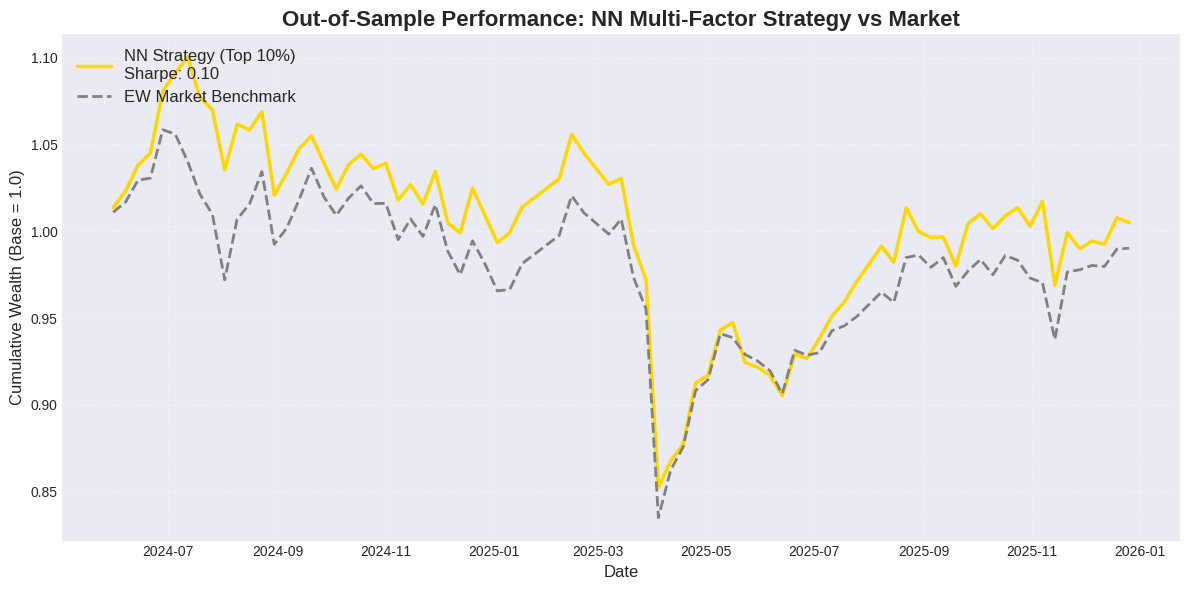

In [34]:
# ==========================================
# 3. 繪製資金曲線對決圖 (NN Strategy vs EW Benchmark)
# ==========================================
# 確保您已經在上一階段跑出了 cum_market_rets (大盤等權重基準)
plt.figure(figsize=(12, 6))

# 畫出 NN 策略的資金曲線
plt.plot(cum_strategy_rets.index, cum_strategy_rets.values, 
         label=f'NN Strategy (Top 10%) \nSharpe: {sharpe_strategy:.2f}', 
         color='gold', linewidth=2.5)

# 畫出全市場等權重基準的資金曲線
plt.plot(cum_market_rets.index, cum_market_rets.values, 
         label='EW Market Benchmark', 
         color='gray', linewidth=2, linestyle='--')

# 圖表美化
plt.title('Out-of-Sample Performance: NN Multi-Factor Strategy vs Market', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Wealth (Base = 1.0)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

<span style='font-size:16px; color:;'>  

## 六. 回測結果結論與實戰洞察 (Conclusion & Insights)

針對 79 週的樣本外（Out-of-sample）測試期間，我們將「神經網路純多頭策略（Top 10%）」與「全市場等權重基準（EW Benchmark）」進行了對比分析。總結得出以下三大核心洞察：

### 1. 成功創造超額報酬 (Alpha Generation)

在長達 79 週的測試期間內，全市場平均表現疲軟，基準模型呈現負報酬（總報酬 -0.97%）。然而，**神經網路策略成功逆勢創造了正報酬（總報酬 +0.50%），打敗大盤約 1.47%**。這證明了模型學習到的多因子非線性特徵，確實具備在橫截面上篩選出強勢股（Winners）的預測能力，而非單純依賴大盤上漲的 Beta 收益。

### 2. 風險調整後表現微幅勝出，但整體市場動能不足

策略的夏普比率（0.10）微幅領先大盤（0.04），顯示其每承擔一單位風險所獲得的報酬確實優於盲目買進全市場。
然而，兩者的絕對數值皆偏低（通常優質策略夏普比率需 > 1.0）。這反映出該測試期間的市場可能處於高度震盪或空頭盤整的「無趨勢（Trendless）」狀態，導致純多頭策略（Long-only）獲利空間受限。

### 3. 下檔風險增加 (Concentration Risk & MDD)

這份回測揭露了一個重要的警訊：**策略的最大區間跌幅（MDD = -22.52%）深於大盤基準（-21.10%）**。
這符合量化財務的預期——當我們將資金高度集中在預測報酬最高的前 10% 股票時（通常是高動能、高波動的標的），雖然能提高攻擊力，但在股災或市場風格切換（Factor Crash）時，缺乏了全市場分散投資的保護傘，導致跌幅比大盤更深。

---

### 💡 實戰優化建議 (Next Steps for Live Trading)

雖然模型具備選股能力（Gross Alpha），但要將其轉化為真實世界的印鈔機，未來還有幾個關鍵的優化方向：

1. **交易成本的致命傷 (Transaction Costs)**：
目前策略的總報酬為 0.50%。如果策略是「每週重新平衡（Weekly Rebalancing）」，頻繁換股產生的手續費與交易稅（台股一買一賣約需 0.4% ~ 0.5% 的摩擦成本）將會瞬間吃掉所有獲利。**下一步必須在回測程式中扣除交易成本**，並考慮降低再平衡頻率（例如改為雙週或每月再平衡）。
2. **加入避險或做空機制 (Long-Short Strategy)**：
既然模型能找出前 10% 的好股，那它應該也能找出最後 10% 的爛股。在台股這種容易暴跌的市場，可以測試「做多前 10%、放空後 10%」的市場中性策略（Market Neutral），藉此消除大盤下跌帶來的 MDD 傷害。
3. **動態部位控管 (Dynamic Position Sizing)**：
為了改善 MDD，可以加入「總體經濟濾網」。例如：當神經網路預測全市場的平均預期報酬為負時，主動將股票部位降至 50% 甚至抱現金，不要硬買前 10% 的股票，這將大幅改善夏普比率。

<span style='font-size:16px; color:;'>  

## 七. 參考文獻

Fama, E. F., & French, K. R. (1993). Common risk factors in the returns on stocks and bonds. Journal of Financial Economics, 33(1), 3-56

Gu, S., Kelly, B., & Xiu, D. (2020). Empirical asset pricing via machine learning. The Review of Financial Studies, 33(5), 2223-2273.

Pan, S., Long, S., Wang, Y., & Xie, Y. (2023). Nonlinear asset pricing in Chinese stock market: A deep learning approach. International Review of Financial Analysis, 87, 102627.

<span style='font-size:16px; color:;'>  

## 附錄：TEJ 原始 Excel 資料庫建置全紀錄 (Data Pipeline)

本區塊記錄了本專案如何將原始的 TEJ (台灣經濟新報) Excel 靜態資料，轉化為具備高頻讀取能力與高效能的 MySQL 關聯式資料庫。

## 1. 專案痛點與目標
* **原始資料限制**：原始資料為 33 個 Excel 檔案（總計約 258MB），涵蓋台股上市櫃公司十年的日資料。若直接使用 Pandas 讀取，極易造成記憶體溢位 (Out of Memory)，且無法進行跨時間、跨標的的極速查詢。
* **建置目標**：打造一個本地端的高效能資料倉儲 (`taiwan_stock_warehouse`)，透過 SQL 引擎進行資料的篩選與運算，大幅降低 Python 端的記憶體負擔，為後續的神經網路模型訓練提供穩定的特徵來源。

---

## 2. 資料處理流水線 (ETL Process)

我們設計了一套自動化的 Python 腳本，結合 `Pandas` 與 `SQLAlchemy`，執行以下關鍵步驟：

### 步驟一：批次讀取與防呆 (Extract)
* 使用 `glob` 模組自動掃描目標資料夾內所有的 `price_*.xlsx` 檔案。
* 針對 TEJ 報表特性，設定 `skiprows=2` 跳過無效的表頭，確保欄位名稱正確對齊。

### 步驟二：髒資料清洗與特徵工程 (Transform)
這是確保資料庫強健度 (Robustness) 最關鍵的一環，我們處理了真實世界中常見的幾種「髒資料」：
1. **日期雜訊處理**：
   * 原始資料中帶有異常單引號（如 `'2015/01/05`）。
   * 透過 `pd.to_datetime(errors='coerce')` 強制轉換，並將無法辨識的極端錯誤日期轉為 `NaT` 後剔除，最後格式化為 MySQL 認得的 `Date` 格式。
2. **第一正規化 (1NF) 與正則表達式 (Regex)**：
   * 原始的 `證券代碼` 欄位混合了代碼與名稱（如 `1104 環泥`）。
   * 利用 Regex `extract(r'([A-Za-z0-9]+)')` 萃取純粹的英文與數字作為 `股票代碼`。
   * 利用 Regex `replace(r"[A-Za-z0-9\'\s]+", "")` 消除非中文字元，萃取出純 `公司名稱`。
3. **空值與財報缺漏處理**：
   * 針對虧損公司無法計算本益比而產生減號 (`-`) 的狀況，使用 `pd.to_numeric(errors='coerce')`，將非數字字元安全地轉換為 `NaN`（寫入資料庫後轉為 `NULL`），避免影響後續的排序與聚合計算。

### 步驟三：資料庫正規化與切割 (Normalize)
為了提升查詢效能與模型訓練的靈活性，我們將原本寬大的 DataFrame 切割為兩張關聯表：
* **`tej_price_daily` (價量表)**：僅包含開、高、低、收、成交量。供模型快速抓取技術面特徵。
* **`tej_factor_daily` (因子表)**：包含週轉率、市值比重、本益比、股價淨值比等。供選股與資產配置使用。
* **關聯鍵 (Keys)**：兩張表皆保留 `股票代碼` 與 `年月日`，未來可隨時透過 `INNER JOIN` 無縫合併。

### 步驟四：精準型態寫入與效能優化 (Load & Optimize)
* **自訂 Data Dictionary**：不依賴 Pandas 的自動型態猜測，手動透過 SQLAlchemy 定義精準的資料型態（如 `Numeric(10, 2)` 處理股價、`BIGINT` 處理龐大的成交量、`VARCHAR(10)` 處理代碼），達到節省空間與避免浮點數誤差的目的。
* **高速複合索引 (B-Tree Index)**：
  * 資料寫入完成後，針對兩張表執行：`CREATE INDEX idx_ticker_date ON table_name (股票代碼, 年月日);`
  * **成效**：將原本需要全表掃描 (Full Table Scan) 數百萬筆資料的查詢，轉化為毫秒級的索引尋址 (Index Lookup)，完美支撐高頻交易回測的效能需求。

---

**總結**：
透過這套 ETL 流水線，我們成功實現了 **「空間換取時間 (Space-Time Tradeoff)」** 的系統設計架構。資料庫的建置不僅解決了 Excel 的容量限制，更讓未來的演算法開發能專注於邏輯運算，將繁重的資料篩選工作完美交接給 MySQL 引擎。